# 05b - Re-embed with OpenAI + t-SNE Visualization

**Why re-embed:**
- BGE-M3 runs locally (133 min on CPU) - OpenAI API is instant
- `text-embedding-3-large` (3072d) has stronger multilingual performance for cross-lingual retrieval
- Bulgarian query → English document retrieval is the exact use case it excels at

**Cost estimate:**
- 2,098 chunks × ~400 tokens avg = ~840K tokens
- $0.00013/1K tokens × 840 = **~$0.11 one-time cost**
- Query embedding at runtime: ~100 tokens per question = $0.000013/question

**Output:**
- `data/vectorstore/henselmans_openai.index` - new FAISS index
- `data/vectorstore/henselmans_openai_metadata.json` - aligned metadata
- t-SNE visualization of the embedding space

In [1]:
import json, os, time
from pathlib import Path
import numpy as np
import faiss
import warnings; warnings.filterwarnings('ignore')

from openai import OpenAI
from dotenv import load_dotenv
load_dotenv(override=True)

from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path().resolve()
BACKEND_DIR = NOTEBOOK_DIR.parent
PROCESSED_DIR = BACKEND_DIR / 'data' / 'processed'
CHUNKS_DIR = PROCESSED_DIR / 'chunks'
VS_DIR = BACKEND_DIR / 'data' / 'vectorstore'
VS_DIR.mkdir(parents=True, exist_ok=True)

openai_client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
EMBED_MODEL = os.getenv('EMBEDDING_MODEL')
EMBED_DIM = 3072
BATCH_SIZE = 100

print('Setup complete')
print(f'Embedding model: {EMBED_MODEL}')
print(f'Dimensions: {EMBED_DIM}')
print(f'Batch size: {BATCH_SIZE}')

Setup complete
Embedding model: text-embedding-3-large
Dimensions: 3072
Batch size: 100


## 1. Load Clean Chunks

In [2]:
data = json.loads((CHUNKS_DIR / 'clean_chunks.json').read_text(encoding='utf-8'))
chunks = data['chunks']
texts = [c['text'] for c in chunks]

total_chars = sum(len(t) for t in texts)
est_tokens = total_chars // 4
est_cost_usd = (est_tokens / 1000) * 0.00013

print(f'Chunks loaded: {len(chunks):,}')
print(f'Total chars: {total_chars:,}')
print(f'Est. tokens: ~{est_tokens:,}')
print(f'Est. cost: ~${est_cost_usd:.3f} USD')

Chunks loaded: 2,098
Total chars: 4,007,803
Est. tokens: ~1,001,950
Est. cost: ~$0.130 USD


## 2. Generate Embeddings (OpenAI Batch API)

In [3]:
def embed_batch(texts_batch: list[str]) -> list[list[float]]:
    """Embed a batch of texts using OpenAI text-embedding-3-large."""
    response = openai_client.embeddings.create(
        model=EMBED_MODEL,
        input=texts_batch,
    )
    # Sort by index to ensure order (OpenAI may return out of order)
    sorted_data = sorted(response.data, key=lambda x: x.index)
    return [item.embedding for item in sorted_data]


all_embeddings = []
print(f'Embedding {len(texts):,} chunks in batches of {BATCH_SIZE}...')

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='Embedding'):
    batch = texts[i : i + BATCH_SIZE]
    embs = embed_batch(batch)
    all_embeddings.extend(embs)
    time.sleep(0.1)  # gentle rate limit respect

embeddings = np.array(all_embeddings, dtype='float32')
print(f'\nEmbeddings shape : {embeddings.shape}')
assert embeddings.shape == (len(chunks), EMBED_DIM), 'Shape mismatch!'
print('Shape OK')

Embedding 2,098 chunks in batches of 100...


Embedding: 100%|██████████| 21/21 [00:27<00:00,  1.31s/it]



Embeddings shape : (2098, 3072)
Shape OK


## 3. Build FAISS Index

In [4]:
# L2-normalize for cosine similarity via inner product
faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(EMBED_DIM)
index.add(embeddings)

index_path = VS_DIR / 'henselmans_openai.index'
faiss.write_index(index, str(index_path))

print(f'FAISS index built and saved')
print(f'  Vectors: {index.ntotal:,}')
print(f'  Dimensions: {EMBED_DIM}')
print(f'  Size: {index_path.stat().st_size / (1024*1024):.1f} MB')

FAISS index built and saved
  Vectors: 2,098
  Dimensions: 3072
  Size: 24.6 MB


## 4. Save Aligned Metadata

In [5]:
metadata = []
for i, c in enumerate(chunks):
    metadata.append({
        'faiss_id': i,
        'chunk_id': c['chunk_id'],
        'source': c['source'],
        'file_type': c['file_type'],
        'text': c['text'],
        'topic_category': c['metadata']['topic_category'],
        'applies_to_level': c['metadata']['applies_to_level'],
        'goal_relevance': c['metadata']['goal_relevance'],
        'is_case_study': c['metadata']['is_case_study'],
        'calculator_context': c['metadata']['calculator_context'],
        'is_calculator_tool': c['metadata'].get('is_calculator_tool', False),
    })

meta_path = VS_DIR / 'henselmans_openai_metadata.json'
meta_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print(f'Metadata saved: {meta_path}')
print(f'Records: {len(metadata):,}')

Metadata saved: D:\Cybernetic Gym Assistant\backend\data\vectorstore\henselmans_openai_metadata.json
Records: 2,098


## 5. t-SNE Visualization

In [7]:
print('Running t-SNE on embeddings...')

# Use PCA init for stability, perplexity=40 good for ~2K points
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42,
    max_iter=1500,
    learning_rate='auto',
    init='pca',
    n_jobs=-1,
)
coords = tsne.fit_transform(embeddings)
print(f't-SNE complete. KL divergence: {tsne.kl_divergence_:.4f}')

Running t-SNE on embeddings...
t-SNE complete. KL divergence: 0.8316


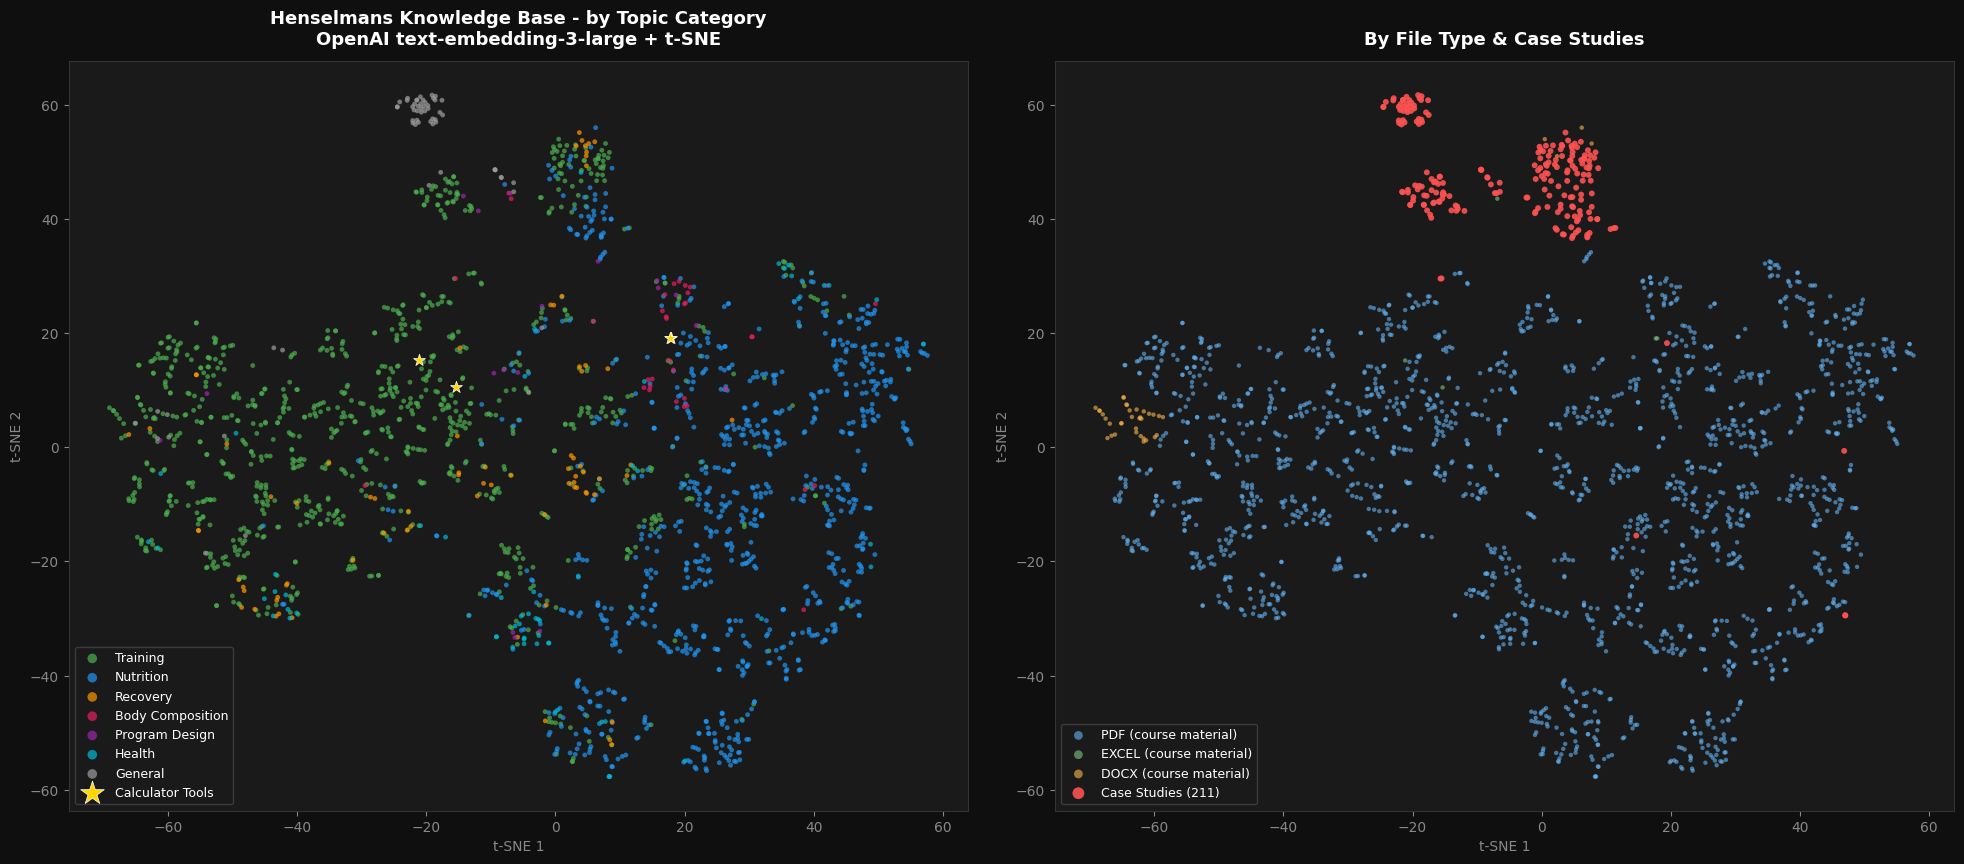


t-SNE saved -> D:\Cybernetic Gym Assistant\backend\data\processed\tsne_visualization.png


In [8]:
# Color scheme by topic category
TOPIC_COLORS = {
    'training': '#4CAF50',
    'nutrition': '#2196F3',
    'recovery': '#FF9800',
    'body_composition': '#E91E63',
    'program_design': '#9C27B0',
    'health': '#00BCD4',
    'general' : '#9E9E9E',
}

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor('#0f0f0f')

def style_ax(ax, title):
    ax.set_facecolor('#1a1a1a')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(colors='#888')
    ax.set_xlabel('t-SNE 1', color='#888')
    ax.set_ylabel('t-SNE 2', color='#888')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

# Plot 1: by topic category
ax1 = axes[0]
style_ax(ax1, 'Henselmans Knowledge Base - by Topic Category\nOpenAI text-embedding-3-large + t-SNE')

topics = [m['topic_category'] for m in metadata]
for topic, color in TOPIC_COLORS.items():
    mask = np.array([t == topic for t in topics])
    if mask.sum() == 0: continue
    ax1.scatter(
        coords[mask, 0], coords[mask, 1],
        c=color, s=12, alpha=0.7, edgecolors='none', label=topic.replace('_', ' ').title()
    )

# Highlight calculator tool chunks
calc_mask = np.array([m.get('is_calculator_tool', False) for m in metadata])
if calc_mask.sum() > 0:
    ax1.scatter(coords[calc_mask, 0], coords[calc_mask, 1],
                c='#FFD700', s=80, marker='*', alpha=1.0,
                edgecolors='white', linewidths=0.5, label='Calculator Tools', zorder=5)

ax1.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white',
           fontsize=9, markerscale=2, loc='lower left')

# Plot 2: by file type + case study
ax2 = axes[1]
style_ax(ax2, 'By File Type & Case Studies')

TYPE_COLORS = {'pdf': '#64B5F6', 'excel': '#81C784', 'docx': '#FFB74D'}
ftypes = [m['file_type'] for m in metadata]
is_cs = [m['is_case_study'] for m in metadata]

for ftype, color in TYPE_COLORS.items():
    mask = np.array([f == ftype and not cs for f, cs in zip(ftypes, is_cs)])
    if mask.sum() == 0: continue
    ax2.scatter(coords[mask, 0], coords[mask, 1],
                c=color, s=10, alpha=0.6, edgecolors='none',
                label=f'{ftype.upper()} (course material)')

# Case studies in distinct color
cs_mask = np.array(is_cs)
if cs_mask.sum() > 0:
    ax2.scatter(coords[cs_mask, 0], coords[cs_mask, 1],
                c='#FF5252', s=18, alpha=0.9, edgecolors='none',
                label=f'Case Studies ({cs_mask.sum()})')

ax2.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white',
           fontsize=9, markerscale=2, loc='lower left')

plt.tight_layout(pad=2)
out_img = PROCESSED_DIR / 'tsne_visualization.png'
plt.savefig(str(out_img), dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'\nt-SNE saved -> {out_img}')

## 6. Retrieval Smoke Test with OpenAI Embeddings

In [9]:
def embed_query_openai(text: str) -> np.ndarray:
    response = openai_client.embeddings.create(model=EMBED_MODEL, input=[text])
    emb = np.array(response.data[0].embedding, dtype='float32').reshape(1, -1)
    faiss.normalize_L2(emb)
    return emb

def retrieve(query: str, k: int = 5) -> list[dict]:
    q_emb = embed_query_openai(query)
    scores, ids = index.search(q_emb, k)
    return [{**metadata[idx], 'score': float(s)} for s, idx in zip(scores[0], ids[0]) if idx != -1]

# Test EN query
print('TEST 1: English query')
for r in retrieve('optimal protein intake for muscle hypertrophy', k=4):
    print(f'[{r["score"]:.4f}] [{r["topic_category"]}] {r["source"][:45]}')
    print(f'{r["text"][:110]}...')
    print()

# Test BG cross-lingual query
print('TEST 2: Bulgarian query (cross-lingual)')
for r in retrieve('колко протеин трябва да приемам за мускулна маса', k=4):
    print(f'[{r["score"]:.4f}] [{r["topic_category"]}] {r["source"][:45]}')
    print(f'{r["text"][:110]}...')
    print()

TEST 1: English query
[0.5944] [nutrition] Protein PTC 2022.pdf
onsuming more protein than that resulted in no benefits for
strength development or muscle growth.

Our meta-a...

[0.5873] [nutrition] Protein PTC 2022.pdf
orporated various groups that consumed a different
protein intake without any other differences between the gr...

[0.5799] [nutrition] Protein PTC 2022.pdf
bodyweight.

However, in obese individuals, 1.8 g/kg/d may be excessive. If you have a reasonably
reliable est...

[0.5622] [nutrition] Protein PTC 2022.pdf
Pea-rice-mix (7:3)
7 %
9 g
Take-home message
To maximize protein balance, it is advisable to consume at least ...

TEST 2: Bulgarian query (cross-lingual)
[0.4429] [nutrition] Protein PTC 2022.pdf
onsuming more protein than that resulted in no benefits for
strength development or muscle growth.

Our meta-a...

[0.4359] [nutrition] Protein PTC 2022.pdf
r foods, such as grains, when bulking.

As such, there is no empirically substantiated reason to think we need.

## 7. Summary

In [11]:
print('=' * 60)
print(f'Embedding model: {EMBED_MODEL} ({EMBED_DIM}d)')
print(f'Chunks embedded: {len(chunks):,}')
print(f'FAISS index: henselmans_openai.index')
print(f'Metadata: henselmans_openai_metadata.json')
print(f't-SNE: tsne_visualization.png')

Embedding model: text-embedding-3-large (3072d)
Chunks embedded: 2,098
FAISS index: henselmans_openai.index
Metadata: henselmans_openai_metadata.json
t-SNE: tsne_visualization.png
